##  Notebook 2 — Model Training Pipeline

This notebook walks through the complete pipeline for training an object detection model, from data preparation to saving the final trained weights.

###  Steps covered:
1. Setup & imports  
2. Load pretrained model  
3. Build datasets & dataloaders (with ground truth visualization)  
4. Define training module  
5. Train the model  
6. Resume training from checkpoint  
7. Save final model  

---

###  Input
- `annotations.json` provided for each dataset split (generated from Notebook 1)

###  Output
- Trained model saved in `saved_model/`  
- Training checkpoints stored in `checkpoints/`  

---

In [ ]:
# ============================================================
#  CONFIG 
# ============================================================
import os

# --- Paths ---
DATASET_BASE    = "dataset"       #  root folder of dataset
CHECKPOINT_DIR  = "checkpoints"   #  where checkpoints are saved
MODEL_SAVE_PATH = "saved_model"   #  where final model is exported
TB_LOG_DIR      = "tb_logs"       #  TensorBoard log folder

# --- Model ---
CHECKPOINT = 'facebook/detr-resnet-50'  #  HuggingFace base checkpoint
IMAGE_SIZE = 480                         #  480 (8GB safe) | 640 | 800 (best, 16GB+)

# --- Subset: how many images (None = use full dataset) ---
TRAIN_SUBSET_SIZE = 10000   #  3k (debug) → 10k (good) → None (full, multi-day)
VAL_SUBSET_SIZE   = 500    #  validation images
STRATIFIED        = True   #  True = rare classes sampled more (recommended)

# --- Training ---
BATCH_SIZE         = 2          #  2 is max safe for 8GB VRAM with DETR@480px
MAX_EPOCHS         = 10         #  epochs to train
LEARNING_RATE      = 1e-4       #  transformer head LR
LR_BACKBONE        = 1e-5       #  backbone LR — keep 10x lower than LR
WEIGHT_DECAY       = 1e-4       #  L2 regularization
GRADIENT_CLIP      = 0.1        #  prevents exploding gradients (keep 0.1)
ACCUM_GRAD_BATCHES = 4          #  effective batch = BATCH_SIZE x ACCUM = 8
PRECISION          = "16-mixed" #  '16-mixed' (fast, saves VRAM) | '32'
SAVE_EVERY_EPOCH   = True       #  True = keep all | False = keep top-3 only

# --- Resume ---
RESUME_CKPT   = "checkpoints/last.ckpt"  #  path to .ckpt to resume from
RESUME_EPOCHS = 20    #  total epochs when resuming 

# --- Classes ---
CLASSES = [
    "traffic light", "traffic sign", "car", "person", "bus",
    "truck", "rider", "bike", "motor", "train", "banner", "tuktuk"
]

SPLITS = {
    "train": os.path.join(DATASET_BASE, "train", "train"),
    "val"  : os.path.join(DATASET_BASE, "val",   "val"),
    "test" : os.path.join(DATASET_BASE, "test",  "test"),
}

print(" Config ready!")
print(f"   Model       : {CHECKPOINT}")
print(f"   Image size  : {IMAGE_SIZE}px")
print(f"   Train subset: {TRAIN_SUBSET_SIZE} (stratified={STRATIFIED})")
print(f"   Epochs      : {MAX_EPOCHS}")
print(f"   Eff. batch  : {BATCH_SIZE} x {ACCUM_GRAD_BATCHES} = {BATCH_SIZE*ACCUM_GRAD_BATCHES}")
print(f"   Precision   : {PRECISION}")

 Config ready!
   Model       : facebook/detr-resnet-50
   Image size  : 480px
   Train subset: 10000 (stratified=True)
   Epochs      : 10
   Eff. batch  : 2 x 4 = 8
   Precision   : 16-mixed


## Cell 1 — Environment & Speed Setup

In [ ]:
import torch, warnings
warnings.filterwarnings('ignore')

# Speed & memory optimizations
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.set_float32_matmul_precision('medium') 
torch.backends.cudnn.benchmark = True         

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {free/1024**3:.1f} GB free / {total/1024**3:.1f} GB total")
    if free/1024**3 < 5:
        print("  Low VRAM — restart kernel before training to clear memory")

PyTorch  : 2.5.1+cu121
Device   : cuda
GPU      : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM     : 6.9 GB free / 8.0 GB total


## Cell 2 — Install (skip if already done)

In [4]:
# Uncomment if needed:
# ! pip install -q transformers pytorch-lightning timm supervision opencv-python

## Cell 3 — Verify Imports

In [ ]:
import torch, transformers, pytorch_lightning, cv2
import numpy as np, matplotlib.pyplot as plt
print(f"torch             : {torch.__version__}")
print(f"transformers      : {transformers.__version__}")
print(f"pytorch_lightning : {pytorch_lightning.__version__}")
print(f"cv2               : {cv2.__version__}")
print("\n All imports OK")

torch             : 2.5.1+cu121
transformers      : 5.3.0
pytorch_lightning : 2.6.1
cv2               : 4.13.0

✅ All imports OK


## Cell 4 — Load Processor Only (NOT the full model yet — save VRAM)

In [7]:
from transformers import DetrImageProcessor
import torch

torch.cuda.empty_cache()

id2label = {i: name for i, name in enumerate(CLASSES)}
label2id = {name: i for i, name in enumerate(CLASSES)}

#  Load ONLY processor here — model loads inside Lightning module at training time
image_processor = DetrImageProcessor.from_pretrained(CHECKPOINT, size=IMAGE_SIZE)

print(f"   Processor loaded")
print(f"   Image size : {IMAGE_SIZE}px")
print(f"   Classes    : {len(CLASSES)}")

   Processor loaded
   Image size : 480px
   Classes    : 12


## Cell 5 — Class Imbalance Analysis

✅ Category ID → Label mapping (FIX applied):
   cat_id=  0 → label=0 → 'traffic light'
   cat_id=  1 → label=1 → 'traffic sign'
   cat_id=  2 → label=2 → 'car'
   cat_id=  3 → label=3 → 'person'
   cat_id=  4 → label=4 → 'bus'
   cat_id=  5 → label=5 → 'truck'
   cat_id=  6 → label=6 → 'rider'
   cat_id=  7 → label=7 → 'bike'
   cat_id=  8 → label=8 → 'motor'
   cat_id=  9 → label=9 → 'train'
   cat_id= 10 → label=10 → 'banner'
   cat_id= 11 → label=11 → 'tuktuk'

Class              Count       %    Imbalance
-----------------------------------------------
traffic light     11,975     4.2%       10.3x  MINORITY
traffic sign      21,928     7.7%        5.6x  MINORITY
car              123,542    43.5%        1.0x
person            31,735    11.2%        3.9x
bus               11,424     4.0%       10.8x  MINORITY
truck             13,577     4.8%        9.1x  MINORITY
rider             10,913     3.8%       11.3x  MINORITY
bike               5,541     1.9%       22.3x  MINORITY
motor    

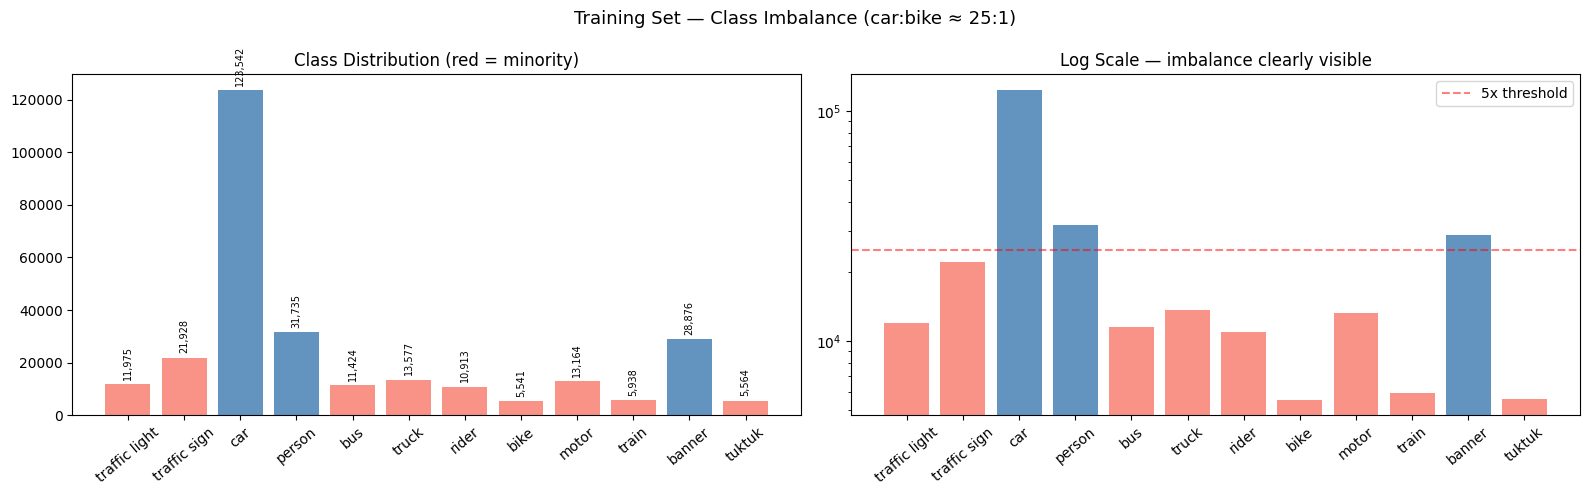


 Saved: class_imbalance.png


In [ ]:
import json, os
import matplotlib.pyplot as plt
from collections import Counter

ann_path = os.path.join(SPLITS["train"], "annotations.json")
with open(ann_path) as f:
    coco_train = json.load(f)

# Category info from actual JSON
cat_id_to_name  = {c["id"]: c["name"] for c in coco_train["categories"]}
cat_id_to_label = {c["id"]: i for i, c in enumerate(coco_train["categories"])}
cat_ids_sorted  = [c["id"] for c in coco_train["categories"]]

print(" Category ID → Label mapping (FIX applied):")
for cid, lidx in cat_id_to_label.items():
    print(f"   cat_id={cid:3d} → label={lidx} → '{cat_id_to_name[cid]}'")

ann_counts   = Counter(a["category_id"] for a in coco_train["annotations"])
class_names  = [cat_id_to_name[cid] for cid in cat_ids_sorted]
class_counts = [ann_counts.get(cid, 0) for cid in cat_ids_sorted]
max_count    = max(class_counts)

print(f"\n{'Class':<15} {'Count':>8} {'%':>7} {'Imbalance':>12}")
print("-" * 47)
for name, count in zip(class_names, class_counts):
    pct   = count / sum(class_counts) * 100
    ratio = max_count / max(count, 1)
    flag  = "  MINORITY" if ratio > 5 else ""
    print(f"{name:<15} {count:>8,} {pct:>7.1f}% {ratio:>10.1f}x{flag}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['salmon' if (max_count/max(c,1)) > 5 else 'steelblue' for c in class_counts]

bars = axes[0].bar(class_names, class_counts, color=colors, alpha=0.85)
axes[0].bar_label(bars, labels=[f'{c:,}' for c in class_counts], fontsize=7, rotation=90, padding=3)
axes[0].set_title("Class Distribution (red = minority)")
axes[0].tick_params(axis='x', rotation=40)

axes[1].bar(class_names, class_counts, color=colors, alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_title("Log Scale — imbalance clearly visible")
axes[1].tick_params(axis='x', rotation=40)
axes[1].axhline(max_count/5, color='red', linestyle='--', alpha=0.5, label='5x threshold')
axes[1].legend()

plt.suptitle("Training Set — Class Imbalance (car:bike ≈ 25:1)", fontsize=13)
plt.tight_layout()
# plt.savefig("class_imbalance.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Saved: class_imbalance.png")

## Cell 6 — Dataset + Stratified Sampling
> **Why stratified?** Random sampling on this dataset picks mostly `car` images.
> Stratified sampling ensures `bike`, `tuktuk`, `train` (25x rarer) still appear meaningfully.

In [9]:
import os, random, torchvision
import numpy as np
from torch.utils.data import DataLoader, Subset
from collections import defaultdict

random.seed(42)
np.random.seed(42)


class CocoDetection(torchvision.datasets.CocoDetection):
    """COCO dataset with corrected category_id → label_index mapping."""
    def __init__(self, split_path, image_processor, train=True):
        ann_file     = os.path.join(split_path, "annotations.json")
        image_folder = os.path.join(split_path, "images")
        super().__init__(image_folder, ann_file)
        self.image_processor = image_processor
        #  FIX: build proper cat_id → contiguous index mapping
        cats = sorted(self.coco.cats.keys())
        self.cat_id_to_label = {cat_id: i for i, cat_id in enumerate(cats)}

    def __getitem__(self, idx):
        images, annotations = super().__getitem__(idx)
        image_id = self.ids[idx]
        #  FIX: remap category_id before passing to processor
        for ann in annotations:
            ann["category_id"] = self.cat_id_to_label.get(
                ann["category_id"], ann["category_id"]
            )
        annotations = {"image_id": image_id, "annotations": annotations}
        encoding = self.image_processor(
            images=images, annotations=annotations, return_tensors="pt"
        )
        return encoding["pixel_values"].squeeze(), encoding["labels"][0]


def stratified_subset(dataset, n_samples):
    """
    Sample images so minority classes get proportionally more coverage.
    For a 25:1 imbalance (car vs bike), this dramatically helps training.
    """
    if n_samples is None or n_samples >= len(dataset):
        return dataset

    # Build class → list of image indices
    class_to_imgs = defaultdict(list)
    for i, img_id in enumerate(dataset.ids):
        anns = dataset.coco.imgToAnns.get(img_id, [])
        seen = set()
        for ann in anns:
            label = dataset.cat_id_to_label.get(ann["category_id"], ann["category_id"])
            if label not in seen:
                class_to_imgs[label].append(i)
                seen.add(label)

    # Budget per class: inversely proportional to class frequency
    class_sizes = {cls: len(imgs) for cls, imgs in class_to_imgs.items()}
    inv_total   = sum(1.0/max(s,1) for s in class_sizes.values())
    budgets     = {
        cls: max(1, int(n_samples * (1.0/max(s,1)) / inv_total))
        for cls, s in class_sizes.items()
    }

    # Pick images starting from rarest class
    selected = set()
    for cls, budget in sorted(budgets.items(), key=lambda x: class_sizes.get(x[0], 999999)):
        candidates = [i for i in class_to_imgs[cls] if i not in selected]
        random.shuffle(candidates)
        selected.update(candidates[:budget])

    # Fill remaining with random images
    remaining = [i for i in range(len(dataset)) if i not in selected]
    random.shuffle(remaining)
    selected.update(remaining[:max(0, n_samples - len(selected))])

    return Subset(dataset, sorted(selected))


def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    return {
        "pixel_values": encoding["pixel_values"],
        "pixel_mask"  : encoding["pixel_mask"],
        "labels"      : [item[1] for item in batch]
    }


print("Loading datasets (COCO indexing)...")
TRAIN_DATASET = CocoDetection(SPLITS["train"], image_processor, train=True)
VAL_DATASET   = CocoDetection(SPLITS["val"],   image_processor, train=False)
TEST_DATASET  = CocoDetection(SPLITS["test"],  image_processor, train=False)

print("Building subsets...")
TRAIN_SUBSET = stratified_subset(TRAIN_DATASET, TRAIN_SUBSET_SIZE) if STRATIFIED else (
    Subset(TRAIN_DATASET, random.sample(range(len(TRAIN_DATASET)), TRAIN_SUBSET_SIZE))
    if TRAIN_SUBSET_SIZE else TRAIN_DATASET
)
VAL_SUBSET = (
    Subset(VAL_DATASET, random.sample(range(len(VAL_DATASET)), VAL_SUBSET_SIZE))
    if VAL_SUBSET_SIZE and VAL_SUBSET_SIZE < len(VAL_DATASET) else VAL_DATASET
)

TRAIN_DATALOADER = DataLoader(
    TRAIN_SUBSET, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=0, pin_memory=True
)
VAL_DATALOADER = DataLoader(
    VAL_SUBSET, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=0, pin_memory=True
)
TEST_DATALOADER = DataLoader(
    TEST_DATASET, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=0, pin_memory=True
)

print(f"\n{'Split':<8} {'Total':>8} {'Used':>8} {'Batches':>8}")
print("-" * 36)
print(f"{'Train':<8} {len(TRAIN_DATASET):>8,} {len(TRAIN_SUBSET):>8,} {len(TRAIN_DATALOADER):>8,}")
print(f"{'Val':<8} {len(VAL_DATASET):>8,} {len(VAL_SUBSET):>8,} {len(VAL_DATALOADER):>8,}")
print(f"{'Test':<8} {len(TEST_DATASET):>8,} {len(TEST_DATASET):>8,} {len(TEST_DATALOADER):>8,}")

# Time estimate
spe = len(TRAIN_DATALOADER)
mins_per_epoch = spe * 0.3 / 60
print(f"\n  Time estimate (RTX 4060, IMAGE_SIZE={IMAGE_SIZE}):")
print(f"   Steps/epoch : {spe:,}")
print(f"   ~{mins_per_epoch:.0f} min/epoch × {MAX_EPOCHS} epochs = ~{mins_per_epoch*MAX_EPOCHS/60:.1f} hrs total")
print("\n Dataloaders ready!")

Loading datasets (COCO indexing)...
loading annotations into memory...
Done (t=0.59s)
creating index...
index created!
loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
Building subsets...

Split       Total     Used  Batches
------------------------------------
Train      48,329   10,000    5,000
Val         6,278      500      250
Test        5,805    5,805    2,903

  Time estimate (RTX 4060, IMAGE_SIZE=480):
   Steps/epoch : 5,000
   ~25 min/epoch × 10 epochs = ~4.2 hrs total

 Dataloaders ready!


## Cell 7 — Sanity Check (validate class IDs are correct)

In [10]:
batch = next(iter(TRAIN_DATALOADER))
print(f"pixel_values : {batch['pixel_values'].shape}")
print(f"pixel_mask   : {batch['pixel_mask'].shape}")
print(f"batch size   : {len(batch['labels'])}")

all_class_ids = []
for lbl in batch['labels']:
    all_class_ids.extend(lbl['class_labels'].tolist())

print(f"class IDs in batch : {sorted(set(all_class_ids))}")
max_cls = max(all_class_ids) if all_class_ids else -1
print(f"max class ID       : {max_cls} (must be < {len(CLASSES)})")

if max_cls >= len(CLASSES):
    print(f"\n ERROR: class ID {max_cls} is out of range!")
    print(f"   Check your category_id mapping in CocoDetection.__getitem__")
else:
    print(f"\n Class IDs valid! All in range [0, {len(CLASSES)-1}]")

pixel_values : torch.Size([2, 3, 480, 853])
pixel_mask   : torch.Size([2, 480, 853])
batch size   : 2
class IDs in batch : [1, 2, 6, 7, 10]
max class ID       : 10 (must be < 12)

 Class IDs valid! All in range [0, 11]


## Cell 8 — Preview Ground Truth Samples

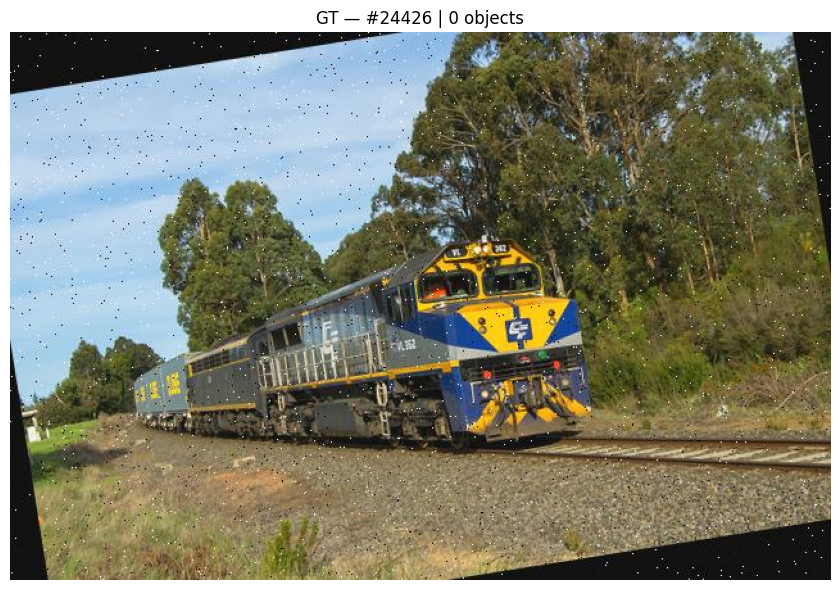

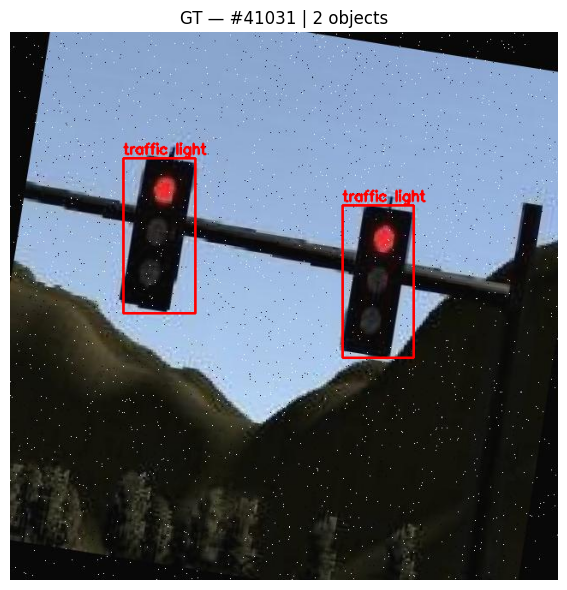

In [ ]:
import random, cv2, os, matplotlib.pyplot as plt

NUM_GT_PREVIEW = 2   
COLORS = [
    (255,0,0),(0,200,0),(0,0,255),(255,200,0),(200,0,200),(0,200,200),
    (180,0,0),(0,130,0),(0,0,180),(180,180,0),(180,0,180),(0,180,180)
]

for _ in range(NUM_GT_PREVIEW):
    img_id   = random.choice(TRAIN_DATASET.ids)
    img_info = TRAIN_DATASET.coco.loadImgs(img_id)[0]
    img_path = os.path.join(TRAIN_DATASET.root, img_info["file_name"])
    image    = cv2.imread(img_path)
    if image is None: continue
    vis  = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).copy()
    anns = TRAIN_DATASET.coco.loadAnns(TRAIN_DATASET.coco.getAnnIds(imgIds=img_id))
    for ann in anns:
        x, y, bw, bh = [int(v) for v in ann["bbox"]]
        label_idx    = TRAIN_DATASET.cat_id_to_label.get(ann["category_id"], 0)
        color        = COLORS[label_idx % len(COLORS)]
        cv2.rectangle(vis, (x, y), (x+bw, y+bh), color, 2)
        cv2.putText(vis, CLASSES[label_idx], (x, max(y-5,10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    plt.figure(figsize=(12, 6))
    plt.imshow(vis)
    plt.title(f"GT — #{img_id} | {len(anns)} objects")
    plt.axis("off"); plt.tight_layout(); plt.show()

## Cell 9 — DETR Lightning Module (with Cosine LR Scheduler)

In [ ]:
import pytorch_lightning as pl
from transformers import DetrForObjectDetection
import torch

class Detr(pl.LightningModule):
    def __init__(self, lr, lr_backbone, weight_decay, num_classes):
        super().__init__()
        self.save_hyperparameters()  #  enables clean load_from_checkpoint
        self.model = DetrForObjectDetection.from_pretrained(
            CHECKPOINT,
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )
        self.lr           = lr
        self.lr_backbone  = lr_backbone
        self.weight_decay = weight_decay

    def forward(self, pixel_values, pixel_mask):
        return self.model(pixel_values=pixel_values, pixel_mask=pixel_mask)

    def common_step(self, batch, batch_idx):
        labels  = [{k: v.to(self.device) for k, v in t.items()} for t in batch["labels"]]
        outputs = self.model(
            pixel_values=batch["pixel_values"],
            pixel_mask  =batch["pixel_mask"],
            labels      =labels
        )
        return outputs.loss, outputs.loss_dict

    def training_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        self.log("train_loss",      loss,                   prog_bar=True,  on_epoch=True, on_step=True)
        self.log("train_loss_ce",   loss_dict["loss_ce"],   prog_bar=False, on_epoch=True)
        self.log("train_loss_bbox", loss_dict["loss_bbox"], prog_bar=False, on_epoch=True)
        self.log("train_loss_giou", loss_dict["loss_giou"], prog_bar=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)
        self.log("val_loss",      loss,                   prog_bar=True,  on_epoch=True)
        self.log("val_loss_ce",   loss_dict["loss_ce"],   prog_bar=False, on_epoch=True)
        self.log("val_loss_bbox", loss_dict["loss_bbox"], prog_bar=False, on_epoch=True)
        self.log("val_loss_giou", loss_dict["loss_giou"], prog_bar=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        m = self.trainer.callback_metrics
        t = m.get('train_loss')
        v = m.get('val_loss')
        t_str = f"{t:.4f}" if t is not None else "N/A"
        v_str = f"{v:.4f}" if v is not None else "N/A"
        print(f"\n Epoch {self.current_epoch+1}/{self.trainer.max_epochs} | train={t_str} | val={v_str}")

    def configure_optimizers(self):
        # Separate LR: lower for pretrained backbone, higher for new head
        param_dicts = [
            {"params": [p for n, p in self.named_parameters()
                        if "backbone" not in n and p.requires_grad]},
            {"params": [p for n, p in self.named_parameters()
                        if "backbone" in n and p.requires_grad],
             "lr": self.lr_backbone},
        ]
        optimizer = torch.optim.AdamW(
            param_dicts, lr=self.lr, weight_decay=self.weight_decay
        )
        # Cosine annealing: gradually reduces LR → smoother convergence
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=MAX_EPOCHS, eta_min=1e-6
        )
        return {"optimizer": optimizer,
                "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}}

    def train_dataloader(self): return TRAIN_DATALOADER
    def val_dataloader(self):   return VAL_DATALOADER


# Test forward pass
torch.cuda.empty_cache()
model = Detr(lr=LEARNING_RATE, lr_backbone=LR_BACKBONE,
             weight_decay=WEIGHT_DECAY, num_classes=len(CLASSES))
model.to(DEVICE)

with torch.no_grad():
    out = model(pixel_values=batch['pixel_values'].to(DEVICE),
                pixel_mask  =batch['pixel_mask'].to(DEVICE))

free, total = torch.cuda.mem_get_info()
print(f"   Forward pass OK")
print(f"   Logits : {out.logits.shape}  → [batch, 100 queries, {len(CLASSES)+1} classes]")
print(f"   Boxes  : {out.pred_boxes.shape}")
print(f"   VRAM   : {(total-free)/1024**3:.1f} GB used / {total/1024**3:.1f} GB total")

Loading weights: 100%|██████████| 530/530 [00:00<00:00, 4026.05it/s]
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.d

   Forward pass OK
   Logits : torch.Size([2, 100, 13])  → [batch, 100 queries, 13 classes]
   Boxes  : torch.Size([2, 100, 4])
   VRAM   : 1.4 GB used / 8.0 GB total


## Cell 10 — Train


In [ ]:
# import os
# from pytorch_lightning import Trainer
# from pytorch_lightning.callbacks import TQDMProgressBar, ModelCheckpoint, LearningRateMonitor
# from pytorch_lightning.loggers import TensorBoardLogger

# os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# os.makedirs(TB_LOG_DIR, exist_ok=True)
# torch.cuda.empty_cache()

# model = Detr(lr=LEARNING_RATE, lr_backbone=LR_BACKBONE,
#              weight_decay=WEIGHT_DECAY, num_classes=len(CLASSES))
# model.to(DEVICE)

# if SAVE_EVERY_EPOCH:
#     ckpt_cb = ModelCheckpoint(
#         dirpath=CHECKPOINT_DIR,
#         filename="epoch{epoch:03d}-val{val_loss:.3f}",
#         save_top_k=-1,         # keep ALL checkpoints
#         every_n_epochs=1,
#         save_last=True
#     )
# else:
#     ckpt_cb = ModelCheckpoint(
#         dirpath=CHECKPOINT_DIR,
#         filename="best-epoch{epoch:03d}-val{val_loss:.3f}",
#         monitor="val_loss", mode="min",
#         save_top_k=3,
#         save_last=True
#     )

# trainer = Trainer(
#     devices=1,
#     accelerator="gpu" if torch.cuda.is_available() else "cpu",
#     max_epochs=MAX_EPOCHS,
#     gradient_clip_val=GRADIENT_CLIP,
#     accumulate_grad_batches=ACCUM_GRAD_BATCHES,
#     precision=PRECISION,
#     log_every_n_steps=10,
#     logger=TensorBoardLogger(TB_LOG_DIR, name="detr_egypt"),
#     callbacks=[
#         TQDMProgressBar(refresh_rate=10),
#         ckpt_cb,
#         LearningRateMonitor(logging_interval='epoch')
#     ]
# )

# print(f"  Training started!")
# print(f"   Epochs      : {MAX_EPOCHS}")
# print(f"   Steps/epoch : {len(TRAIN_DATALOADER)}")
# print(f"   Eff. batch  : {BATCH_SIZE * ACCUM_GRAD_BATCHES}")
# print(f"   TensorBoard : tensorboard --logdir {TB_LOG_DIR}")
# print(f"   Checkpoints : {CHECKPOINT_DIR}/")

# trainer.fit(model)

Loading weights: 100%|██████████| 530/530 [00:00<00:00, 6463.43it/s]
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.d

  Training started!
   Epochs      : 10
   Steps/epoch : 500
   Eff. batch  : 8
   TensorBoard : tensorboard --logdir tb_logs
   Checkpoints : checkpoints/


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                   ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ model │ DetrForObjectDetection │ 41.5 M │ eval │     0 │
└───┴───────┴────────────────────────┴────────┴──────┴───────┘

Trainable params: 41.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 41.5 M                                                                                               
Total estimated model params size (MB): 166                                                                        
Modules in train mode: 0                                                                                           
Modules in eval mode: 410                                                                                          
Total FLOPs: 0

Epoch 0: 100%|██████████| 500/500 [02:09<00:00,  3.85it/s, v_num=2, train_loss_step=2.600, val_loss=1.920, train_loss_epoch=2.420]
 Epoch 1/10 | train=2.4162 | val=1.9213
Epoch 1: 100%|██████████| 500/500 [02:07<00:00,  3.91it/s, v_num=2, train_loss_step=1.750, val_loss=1.620, train_loss_epoch=1.830]
 Epoch 2/10 | train=1.8286 | val=1.6226
Epoch 2: 100%|██████████| 500/500 [02:12<00:00,  3.76it/s, v_num=2, train_loss_step=1.410, val_loss=1.540, train_loss_epoch=1.580]
 Epoch 3/10 | train=1.5783 | val=1.5374
Epoch 3: 100%|██████████| 500/500 [02:04<00:00,  4.02it/s, v_num=2, train_loss_step=1.940, val_loss=1.320, train_loss_epoch=1.420]
 Epoch 4/10 | train=1.4170 | val=1.3214
Epoch 4: 100%|██████████| 500/500 [02:07<00:00,  3.92it/s, v_num=2, train_loss_step=1.390, val_loss=1.290, train_loss_epoch=1.270]
 Epoch 5/10 | train=1.2692 | val=1.2912
Epoch 5: 100%|██████████| 500/500 [02:06<00:00,  3.96it/s, v_num=2, train_loss_step=1.670, val_loss=1.230, train_loss_epoch=1.180]
 Epoch 6/10 | 

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 500/500 [02:14<00:00,  3.71it/s, v_num=2, train_loss_step=1.120, val_loss=1.140, train_loss_epoch=0.903]


## Cell 11 — Resume Training from Checkpoint

In [13]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import TQDMProgressBar, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

ckpt_path = RESUME_CKPT or os.path.join(CHECKPOINT_DIR, "last.ckpt")

if not os.path.exists(ckpt_path):
    print(f" Checkpoint not found: {ckpt_path}")
    print("   Set RESUME_CKPT in the CONFIG cell.")
else:
    print(f" Resuming from: {ckpt_path}")
    model_r = Detr.load_from_checkpoint(
        ckpt_path,
        lr=LEARNING_RATE, lr_backbone=LR_BACKBONE,
        weight_decay=WEIGHT_DECAY, num_classes=len(CLASSES)
    )
    trainer_r = Trainer(
        devices=1,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        max_epochs=RESUME_EPOCHS,
        gradient_clip_val=GRADIENT_CLIP,
        accumulate_grad_batches=ACCUM_GRAD_BATCHES,
        precision=PRECISION,
        log_every_n_steps=10,
        logger=TensorBoardLogger(TB_LOG_DIR, name="detr_egypt_resumed"),
        callbacks=[
            TQDMProgressBar(refresh_rate=10),
            ModelCheckpoint(
                dirpath=CHECKPOINT_DIR,
                filename="resumed-epoch{epoch:03d}-val{val_loss:.3f}",
                save_top_k=-1 if SAVE_EVERY_EPOCH else 3,
                every_n_epochs=1, save_last=True
            ),
            LearningRateMonitor(logging_interval='epoch')
        ]
    )
    trainer_r.fit(model_r, ckpt_path=ckpt_path)
    model = model_r
    print("\n Resumed training complete!")

 Resuming from: checkpoints/last.ckpt


Loading weights: 100%|██████████| 530/530 [00:00<00:00, 4454.28it/s]
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.d

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                   ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ model │ DetrForObjectDetection │ 41.5 M │ eval │     0 │
└───┴───────┴────────────────────────┴────────┴──────┴───────┘

Trainable params: 41.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 41.5 M                                                                                               
Total estimated model params size (MB): 166                                                                        
Modules in train mode: 0                                                                                           
Modules in eval mode: 410                                                                                          
Total FLOPs: 0

Restored all states from the checkpoint at checkpoints/last.ckpt


Epoch 10: 100%|██████████| 5000/5000 [23:01<00:00,  3.62it/s, v_num=1, train_loss_step=1.340, val_loss=1.140, train_loss_epoch=1.160]
 Epoch 11/20 | train=1.1609 | val=1.1424
Epoch 11:  11%|█▏        | 570/5000 [02:04<16:07,  4.58it/s, v_num=1, train_loss_step=0.693, val_loss=1.140, train_loss_epoch=1.160] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

## Cell 12 — Save Final Model

In [ ]:
import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
model.model.save_pretrained(MODEL_SAVE_PATH)
image_processor.save_pretrained(MODEL_SAVE_PATH)

print(f" Model saved to: {MODEL_SAVE_PATH}/")
total_mb = 0
for f in sorted(os.listdir(MODEL_SAVE_PATH)):
    mb = os.path.getsize(os.path.join(MODEL_SAVE_PATH, f)) / 1024**2
    total_mb += mb
    print(f"   {f:<40} {mb:.1f} MB")
print(f"   {'TOTAL':<40} {total_mb:.1f} MB")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 11.17it/s]

✅ Model saved to: saved_model/
   config.json                              0.0 MB
   model.safetensors                        158.8 MB
   preprocessor_config.json                 0.0 MB
   TOTAL                                    158.8 MB


## Cell 13 — List All Checkpoints

In [14]:
import os
ckpts = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.ckpt')])
print(f"Checkpoints in '{CHECKPOINT_DIR}/' ({len(ckpts)} files):")
print("-" * 65)
for ckpt in ckpts:
    mb = os.path.getsize(os.path.join(CHECKPOINT_DIR, ckpt)) / 1024**2
    print(f"   {ckpt:<50} {mb:.0f} MB")
last = os.path.join(CHECKPOINT_DIR, 'last.ckpt')
print(f"\nTo resume: set RESUME_CKPT = '{last}'")

Checkpoints in 'checkpoints/' (12 files):
-----------------------------------------------------------------
   epochepoch=000-valval_loss=1.921.ckpt              476 MB
   epochepoch=001-valval_loss=1.623.ckpt              476 MB
   epochepoch=002-valval_loss=1.537.ckpt              476 MB
   epochepoch=003-valval_loss=1.321.ckpt              476 MB
   epochepoch=004-valval_loss=1.291.ckpt              476 MB
   epochepoch=005-valval_loss=1.230.ckpt              476 MB
   epochepoch=006-valval_loss=1.183.ckpt              476 MB
   epochepoch=007-valval_loss=1.171.ckpt              476 MB
   epochepoch=008-valval_loss=1.145.ckpt              476 MB
   epochepoch=009-valval_loss=1.142.ckpt              476 MB
   last.ckpt                                          476 MB
   resumed-epochepoch=010-valval_loss=1.142.ckpt      476 MB

To resume: set RESUME_CKPT = 'checkpoints\last.ckpt'
